In [65]:
from pathlib import Path
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_FILE = ROOT / "data" / "4-13-2026 754am-358pm.txt"
SCHEDULE_FILE = ROOT / "data" / "AIEB 354 Enrollment Numbers.txt"
START_TIME = pd.Timestamp("2026-04-13 07:54:00")

SAMPLE_SECONDS = 0.0001
AVERAGE_WINDOW_SECONDS = 0.5
CHUNK_MINUTES = 30

In [66]:
df = pd.read_csv(DATA_FILE, sep='\t', header=None, names=['C8-1(v)', 'C13-1(v)', 'C8-7(v)', 'C13-7(v)', 'Time'])

In [67]:
df['Time'] = (df.index * 0.0001) + 0.0001

In [68]:
df.shape

(110082000, 5)

In [69]:
df.head()

,C8-1(v),C13-1(v),C8-7(v),C13-7(v),Time
0,0.000105,-0.000426,0.002967,0.000156,0.0001
1,0.000050,-0.000432,0.002936,0.000180,0.0002
2,0.000051,-0.000398,0.002916,0.000163,0.0003
3,0.000063,-0.000429,0.002952,0.000156,0.0004
4,0.000020,-0.000442,0.002921,0.000160,0.0005


In [70]:
sensor_columns = [column for column in df.columns if column != 'Time']
samples_per_second = int(1 / SAMPLE_SECONDS)
samples_per_window = int(AVERAGE_WINDOW_SECONDS / SAMPLE_SECONDS)
windows_per_chunk = int((CHUNK_MINUTES * 60) / AVERAGE_WINDOW_SECONDS)
day_code = START_TIME.strftime('%A')[0]

def parse_class_time(time_range: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    start_str = time_range[:6]
    end_str = time_range[7:]
    start = pd.to_datetime(
        f"{START_TIME.date()} {start_str}",
        format='%Y-%m-%d %I%M%p',
    )
    end = pd.to_datetime(
        f"{START_TIME.date()} {end_str}",
        format='%Y-%m-%d %I%M%p',
    )
    return start, end

class_blocks = []
for raw_line in SCHEDULE_FILE.read_text().splitlines():
    line = raw_line.strip()
    if not line or 'AIEB 354' not in line:
        continue

    match = re.search(r'(\d{4}am-\d{4}pm|\d{4}am-\d{4}am|\d{4}pm-\d{4}pm)\s+([MTWRF]+)', line)
    if not match:
        continue

    time_range, meeting_days = match.groups()
    if day_code not in meeting_days:
        continue

    start, end = parse_class_time(time_range)
    class_blocks.append(
        {
            'course': line.split()[0],
            'start': start,
            'end': end,
        }
    )

class_blocks = pd.DataFrame(class_blocks).sort_values('start').reset_index(drop=True)

window_means = (
    df.assign(window=df.index // samples_per_window)
      .groupby('window')[sensor_columns]
      .mean()
      .reset_index()
)

window_means['chunk'] = window_means['window'] // windows_per_chunk
window_means['seconds_in_chunk'] = (
    (window_means['window'] % windows_per_chunk) * AVERAGE_WINDOW_SECONDS
)
window_means['clock_time'] = START_TIME + pd.to_timedelta(
    window_means['window'] * AVERAGE_WINDOW_SECONDS,
    unit='s',
)

transformation_summary = pd.DataFrame(
    [
        {
            'Step': 'Raw sampling',
            'Description': (
                f'Each sensor is sampled every {SAMPLE_SECONDS} seconds '
                f'({samples_per_second:,} samples/second).'
            ),
        },
        {
            'Step': 'Time alignment',
            'Description': (
                f'Rows are converted to timestamps starting at {START_TIME:%Y-%m-%d %I:%M %p}.'
            ),
        },
        {
            'Step': 'Window averaging',
            'Description': (
                f'Every {samples_per_window:,} raw samples are averaged into one '
                f'{AVERAGE_WINDOW_SECONDS}-second point.'
            ),
        },
        {
            'Step': '30-minute chunking',
            'Description': (
                f'Windowed data are split into {CHUNK_MINUTES}-minute chunks '
                f'({windows_per_chunk:,} averaged points per chunk).'
            ),
        },
        {
            'Step': 'Consistent scaling',
            'Description': 'Each sensor keeps the same y-axis limits across all chunks.'
        },
        {
            'Step': 'Schedule overlay',
            'Description': (
                'Monday class times for AIEB 354 are drawn as translucent orange blocks.'
            ),
        },
    ]
)

transformation_summary

,Step,Description
0,Raw sampling,Each sensor is sampled every 0.0001 seconds (1...
1,Time alignment,Rows are converted to timestamps starting at 2...
2,Window averaging,"Every 5,000 raw samples are averaged into one ..."
3,30-minute chunking,Windowed data are split into 30-minute chunks ...
4,Consistent scaling,Each sensor keeps the same y-axis limits acros...
5,Schedule overlay,Monday class times for AIEB 354 are drawn as t...


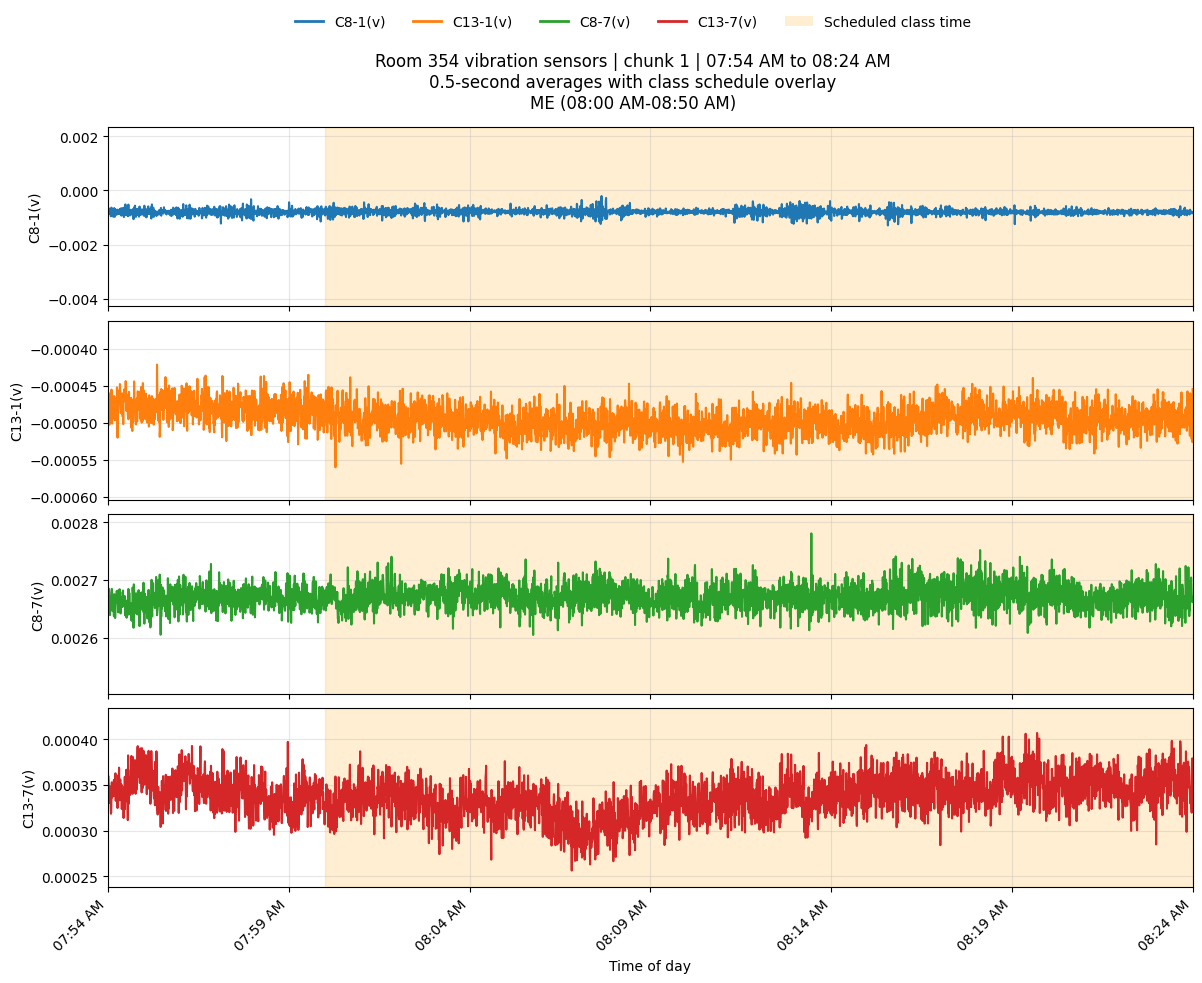

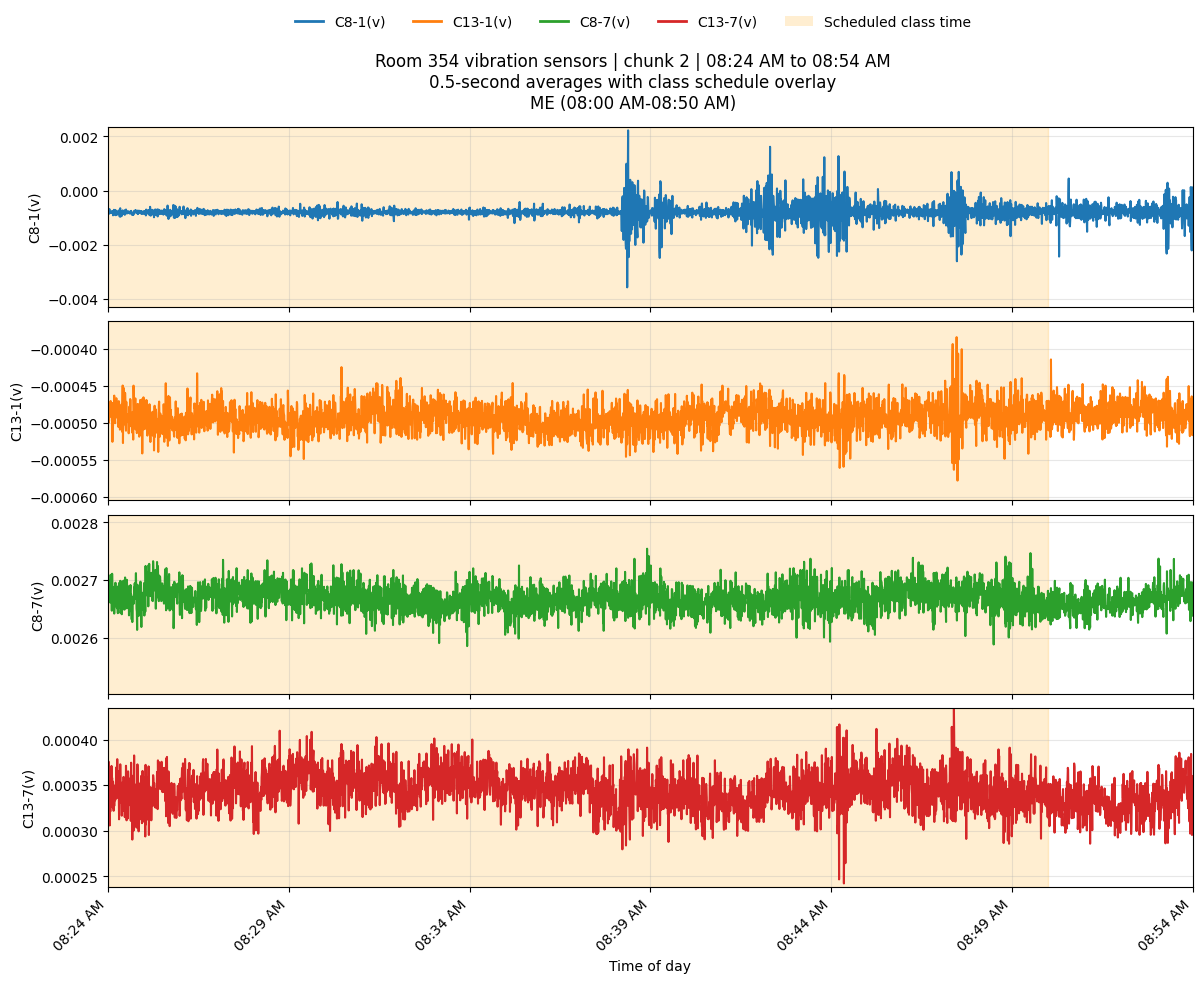

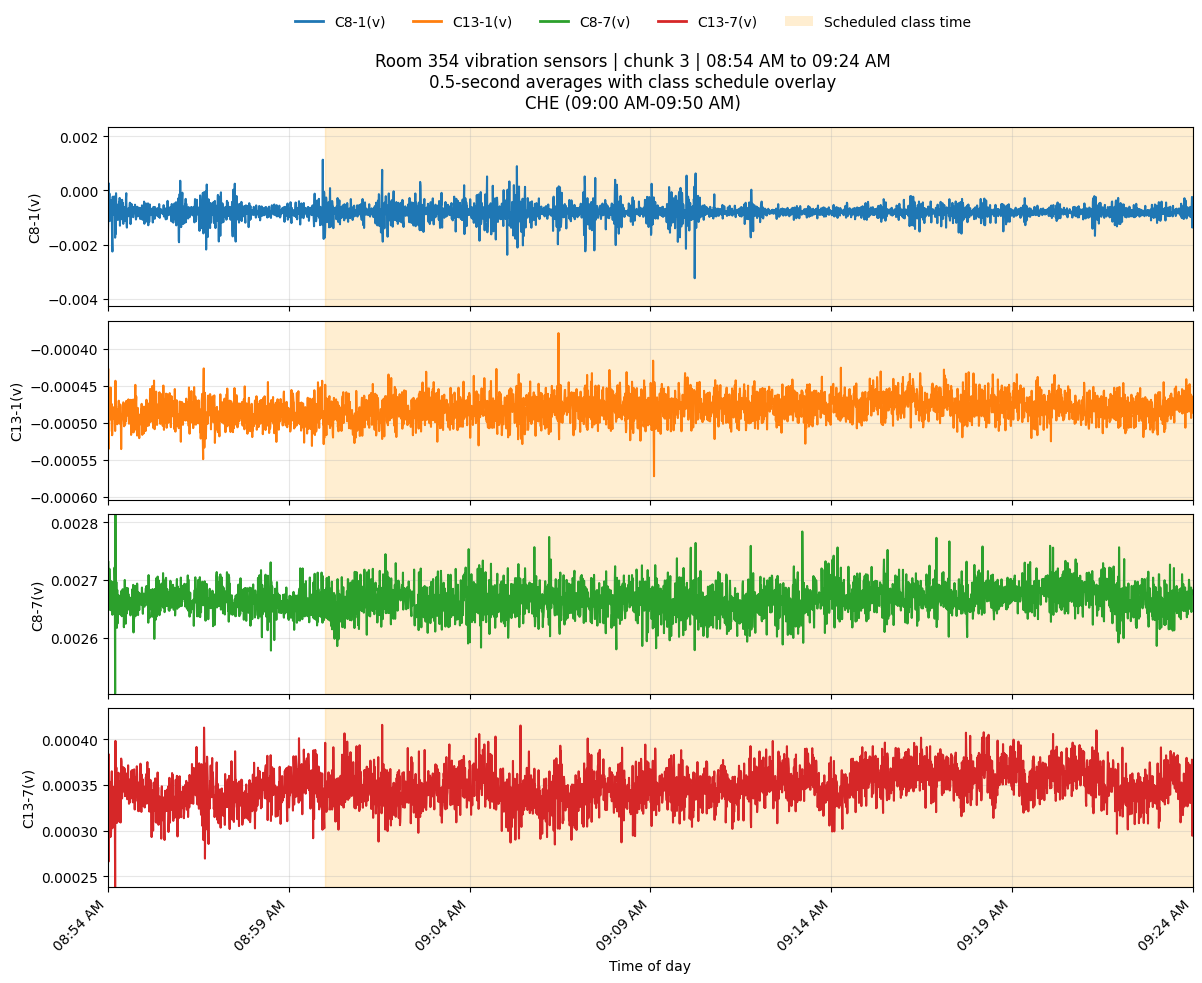

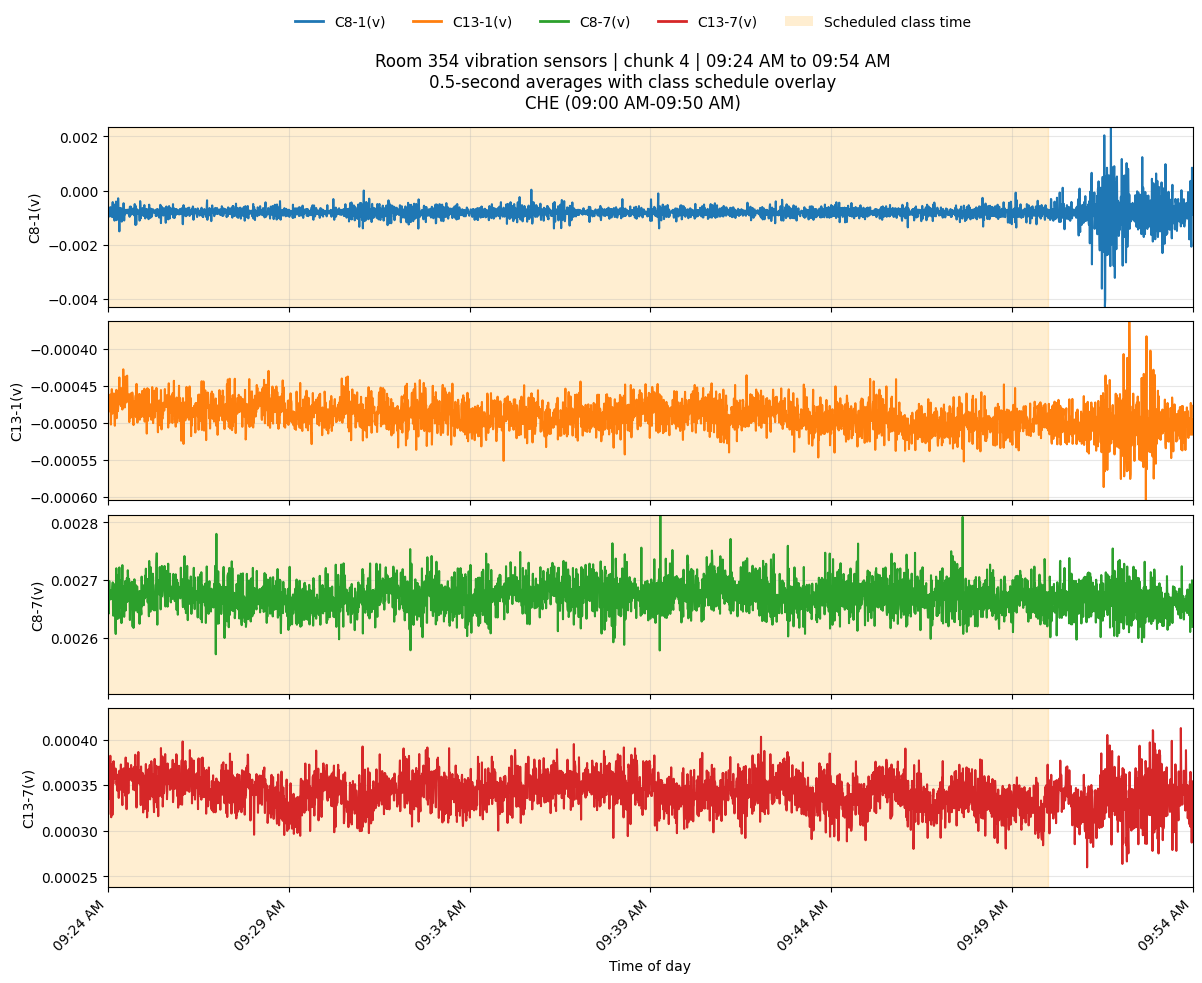

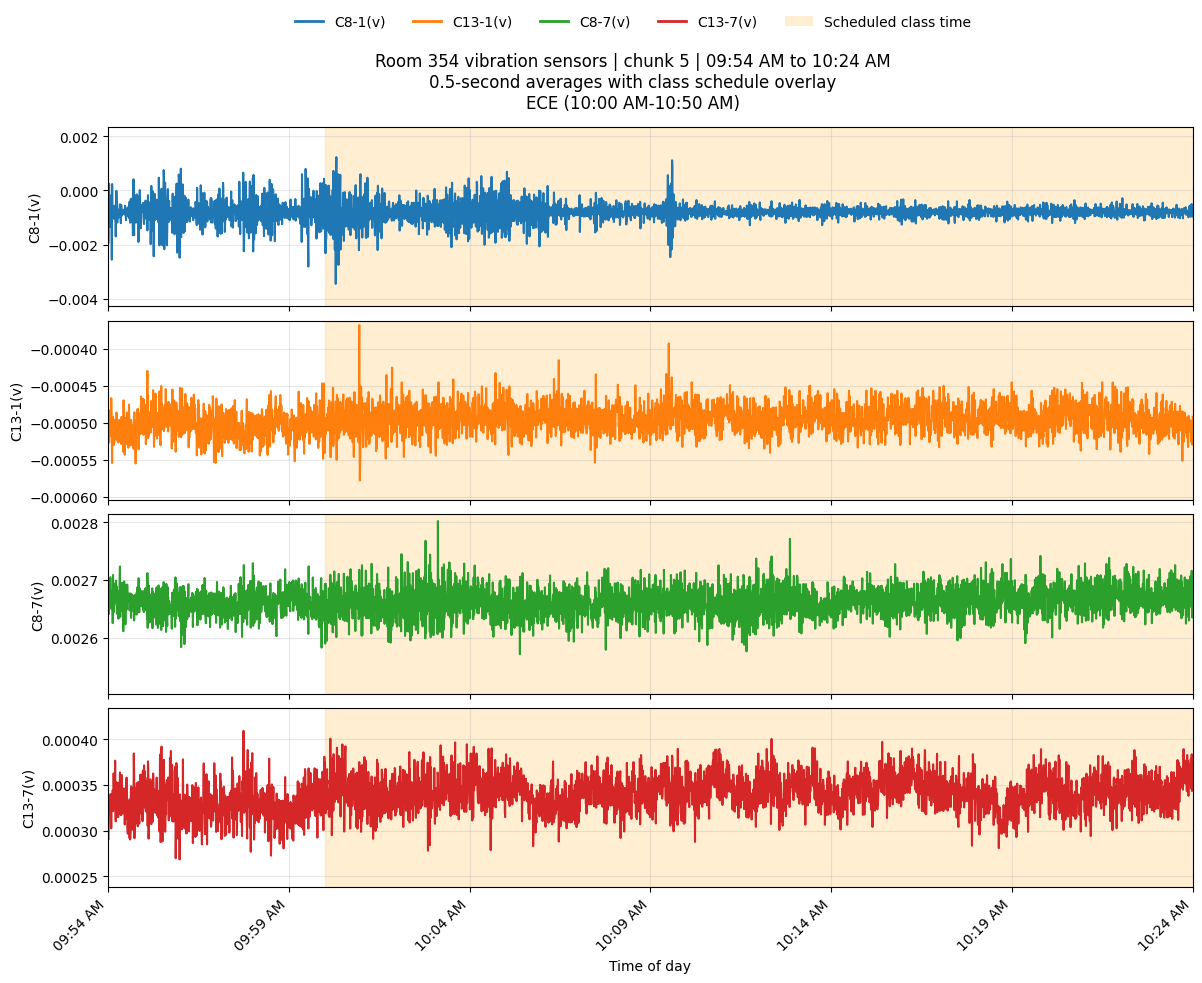

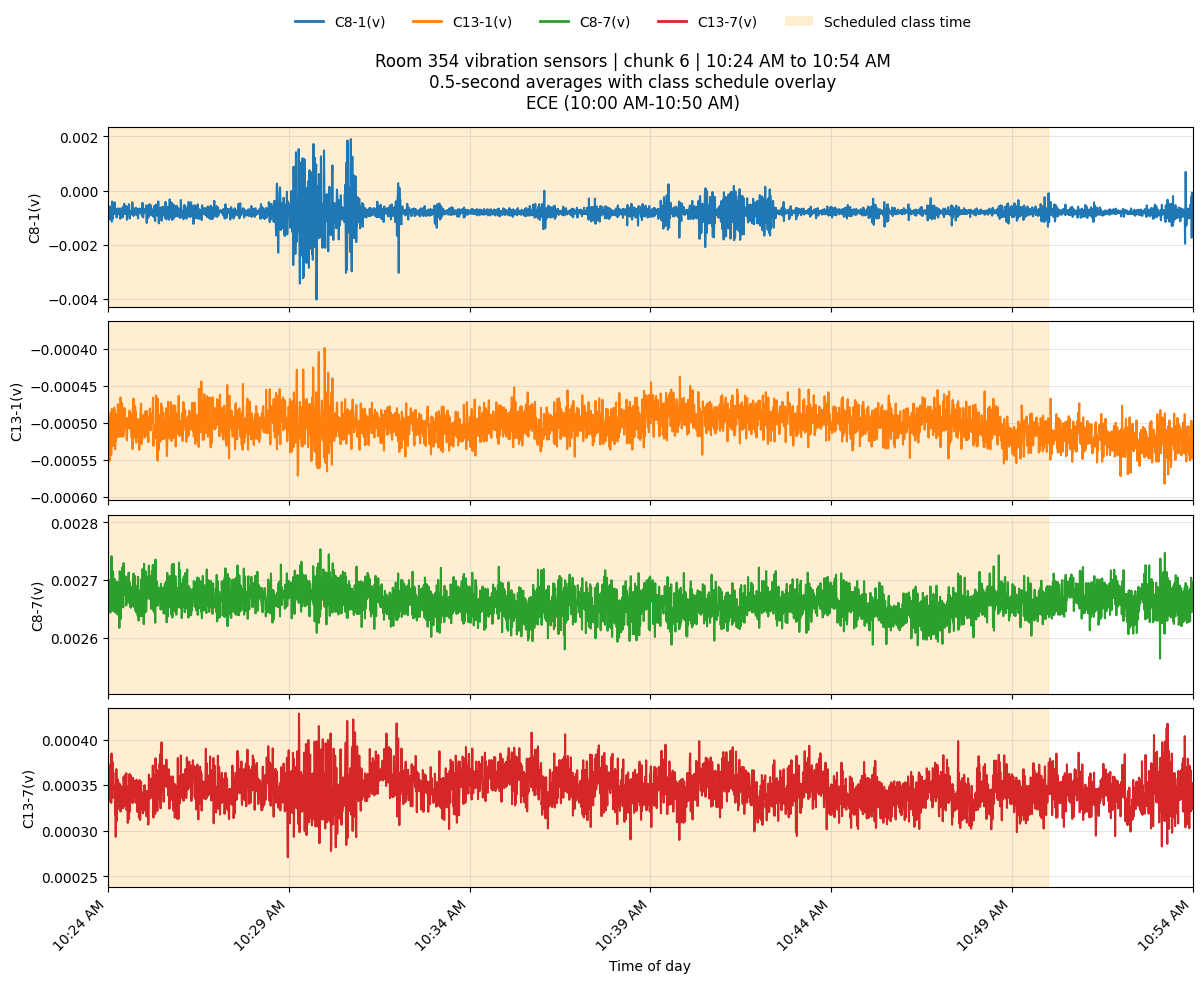

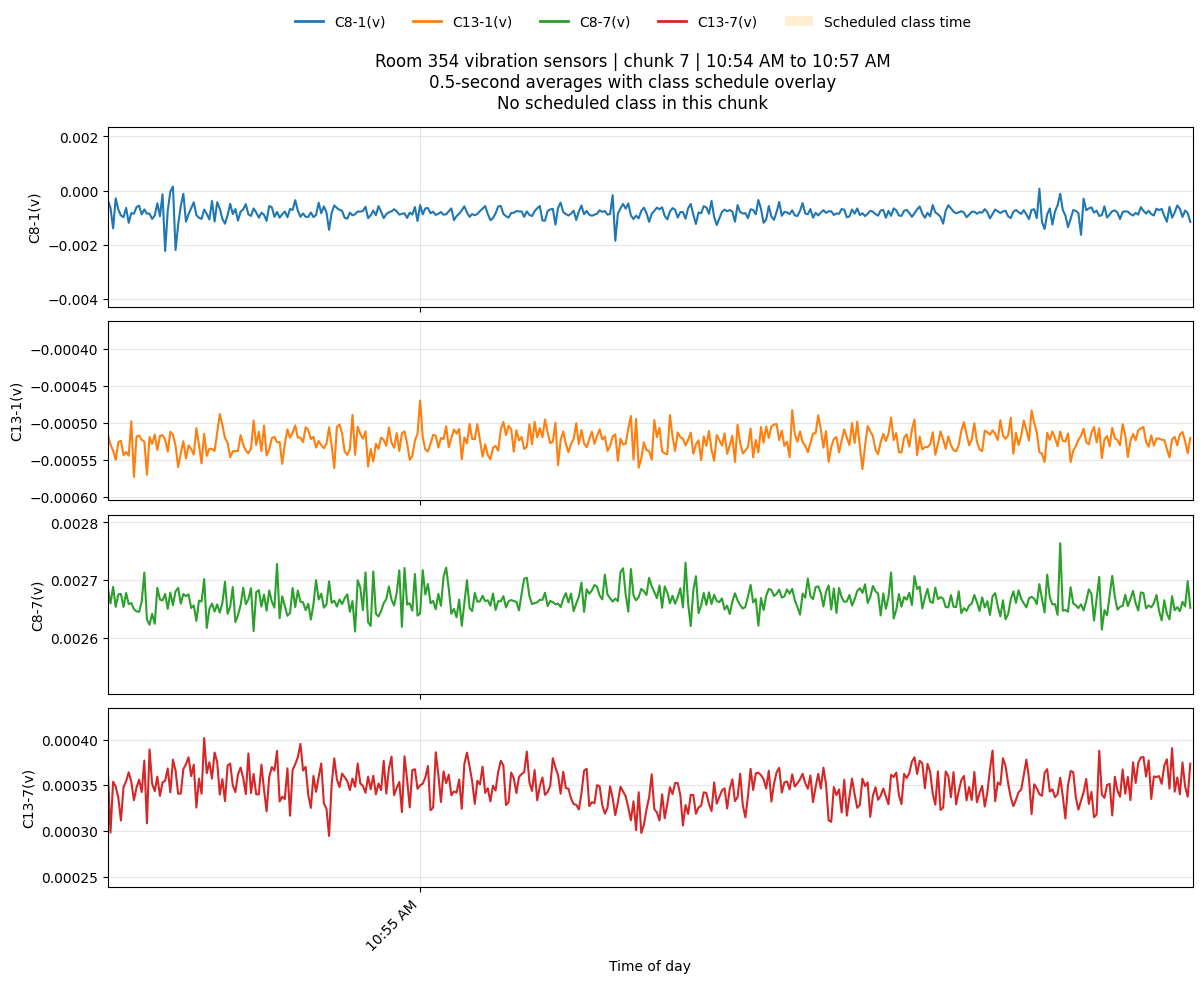

In [71]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sensor_output_dir = ROOT / 'reports' / 'figures' / 'room354_vibration_chunks'
sensor_output_dir.mkdir(parents=True, exist_ok=True)

sensor_colors = dict(zip(sensor_columns, plt.cm.tab10.colors[:len(sensor_columns)]))

y_limits = {
    sensor: (window_means[sensor].min(), window_means[sensor].max())
    for sensor in sensor_columns
}

chunk_count = int(window_means['chunk'].max()) + 1

for chunk_number in range(chunk_count):
    chunk_data = window_means.loc[window_means['chunk'] == chunk_number]
    if chunk_data.empty:
        continue

    chunk_start = chunk_data['clock_time'].iloc[0]
    chunk_end = chunk_data['clock_time'].iloc[-1] + pd.to_timedelta(
        AVERAGE_WINDOW_SECONDS,
        unit='s',
    )
    chunk_classes = class_blocks.loc[
        (class_blocks['start'] < chunk_end) & (class_blocks['end'] > chunk_start)
    ]

    fig, axes = plt.subplots(
        len(sensor_columns),
        1,
        figsize=(14, 10),
        sharex=True,
    )

    if len(sensor_columns) == 1:
        axes = [axes]

    for ax, sensor in zip(axes, sensor_columns):
        ax.plot(
            chunk_data['clock_time'],
            chunk_data[sensor],
            linewidth=1.5,
            color=sensor_colors[sensor],
            label=sensor,
        )

        for _, class_row in chunk_classes.iterrows():
            block_start = max(class_row['start'], chunk_start)
            block_end = min(class_row['end'], chunk_end)
            ax.axvspan(block_start, block_end, color='orange', alpha=0.18)

        ax.set_ylim(y_limits[sensor])
        ax.set_ylabel(sensor)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))

    axes[-1].set_xlim(chunk_start, chunk_end)
    axes[-1].set_xlabel('Time of day')
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

    sensor_handles = [
        Line2D([0], [0], color=sensor_colors[sensor], lw=2, label=sensor)
        for sensor in sensor_columns
    ]
    class_handle = Patch(facecolor='orange', alpha=0.18, label='Scheduled class time')
    fig.legend(
        handles=sensor_handles + [class_handle],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=len(sensor_columns) + 1,
        frameon=False,
    )

    class_text = 'No scheduled class in this chunk'
    if not chunk_classes.empty:
        class_text = '; '.join(
            f"{row.course} ({row.start:%I:%M %p}-{row.end:%I:%M %p})"
            for row in chunk_classes.itertuples()
        )

    fig.suptitle(
        f'Room 354 vibration sensors | chunk {chunk_number + 1} | '
        f'{chunk_start:%I:%M %p} to {chunk_end:%I:%M %p}\n'
        f'{AVERAGE_WINDOW_SECONDS}-second averages with class schedule overlay\n'
        f'{class_text}',
        y=0.945,
    )
    fig.subplots_adjust(top=0.87, hspace=0.08)
    sensor_filename = (
        f'room354_vibration_chunk_{chunk_number + 1:02d}_'
        f'{chunk_start:%H%M}_to_{chunk_end:%H%M}.png'
    )
    fig.savefig(sensor_output_dir / sensor_filename, dpi=300, bbox_inches='tight')
    plt.show()


## Activity Index For Occupancy Cues

This section builds a room-level movement signal from the vibration sensors.

- The raw sensor voltages are already averaged into `0.5`-second windows.
- For each sensor, a rolling RMS and rolling standard deviation are computed over a `10`-second window.
- Each sensor feature is normalized with a z-score so sensors with different voltage ranges can be compared fairly.
- The normalized RMS and standard deviation are averaged into a single per-sensor activity score.
- The four sensor activity scores are then averaged into one room-level activity index.

Higher values in the activity index suggest more short-term vibration energy and variability, which may correspond to people entering, leaving, or moving within the room.

In [72]:
ACTIVITY_WINDOW_SECONDS = 10
activity_window_points = int(ACTIVITY_WINDOW_SECONDS / AVERAGE_WINDOW_SECONDS)

activity_features = window_means[['clock_time', 'chunk']].copy()

for sensor in sensor_columns:
    activity_features[f'{sensor}_rms'] = (
        window_means[sensor]
        .pow(2)
        .rolling(activity_window_points, min_periods=1)
        .mean()
        .pow(0.5)
    )
    activity_features[f'{sensor}_std'] = (
        window_means[sensor]
        .rolling(activity_window_points, min_periods=1)
        .std()
        .fillna(0)
    )

def zscore(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / std

sensor_activity_columns = []
for sensor in sensor_columns:
    rms_z = zscore(activity_features[f'{sensor}_rms'])
    std_z = zscore(activity_features[f'{sensor}_std'])
    activity_features[f'{sensor}_activity'] = (rms_z + std_z) / 2
    sensor_activity_columns.append(f'{sensor}_activity')

activity_features['room_activity_index'] = activity_features[sensor_activity_columns].mean(axis=1)

activity_features[['clock_time', 'room_activity_index'] + sensor_activity_columns].head()

,clock_time,room_activity_index,C8-1(v)_activity,C13-1(v)_activity,C8-7(v)_activity,C13-7(v)_activity
0,2026-04-13 07:54:00.000,-1.985447,-1.235893,-2.044718,-2.130310,-2.530866
1,2026-04-13 07:54:00.500,-0.883845,-1.044548,-1.496721,-1.455608,0.461497
2,2026-04-13 07:54:01.000,-0.583928,-0.834182,-0.990060,-0.464924,-0.046544
3,2026-04-13 07:54:01.500,-0.466339,-0.770917,-0.489220,-0.212052,-0.393168
4,2026-04-13 07:54:02.000,-0.565011,-0.830468,-0.614415,-0.283371,-0.531789


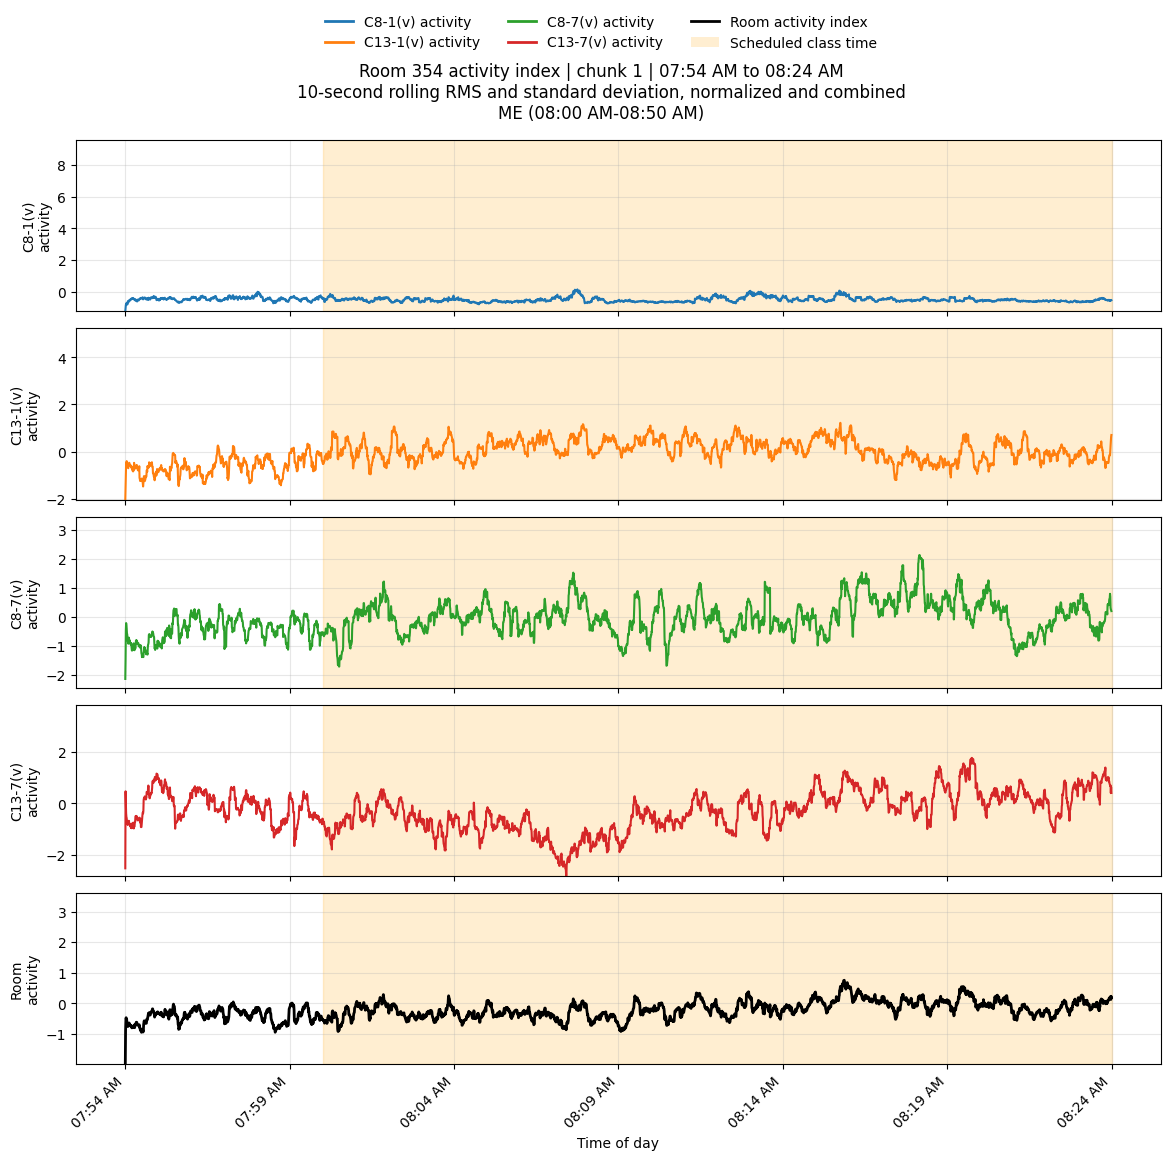

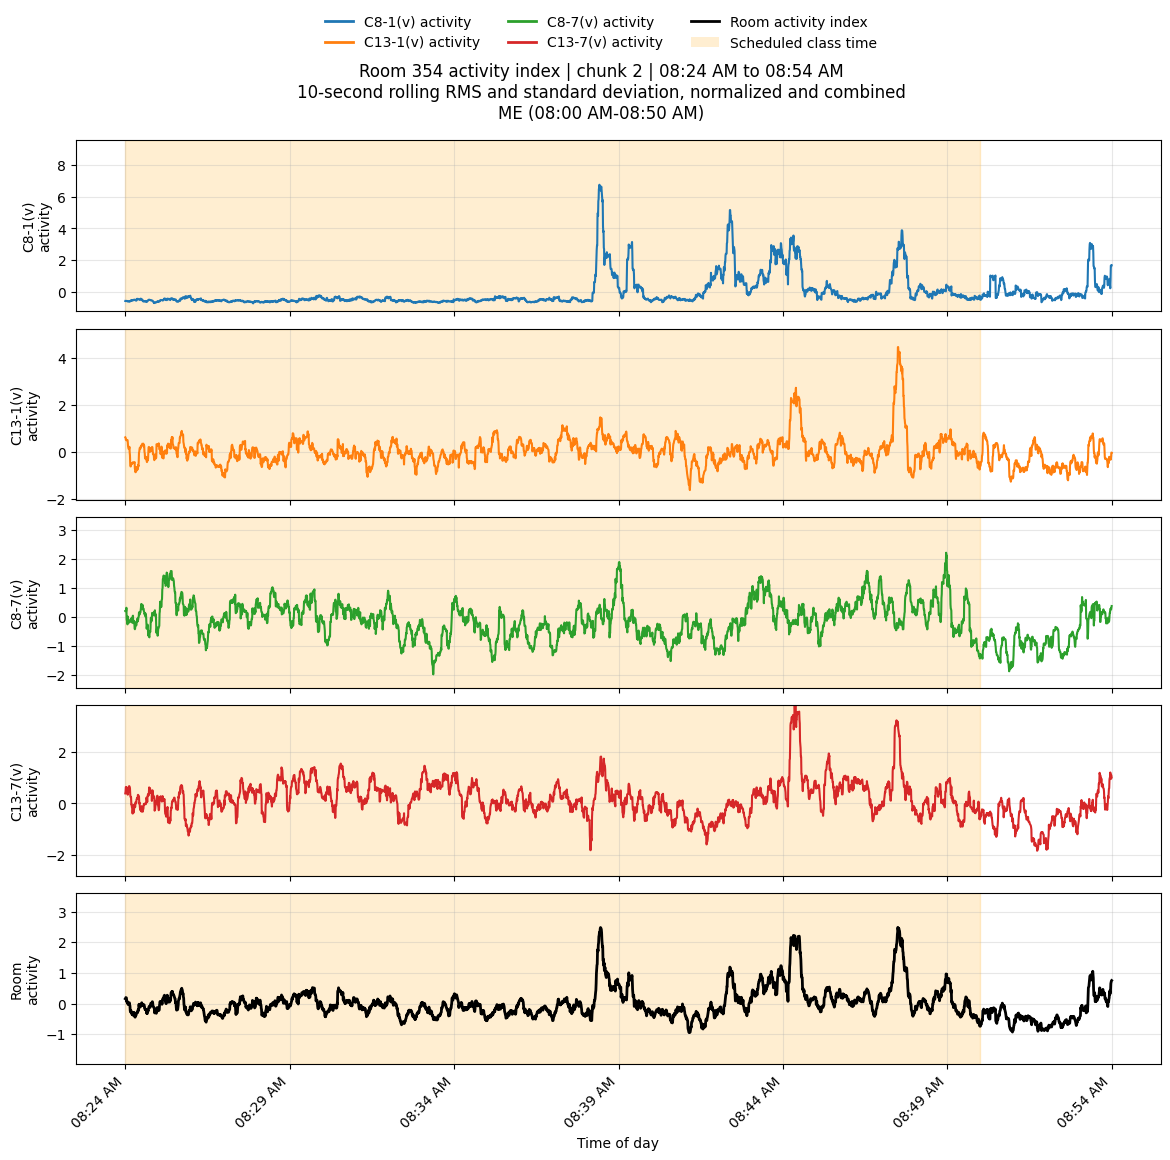

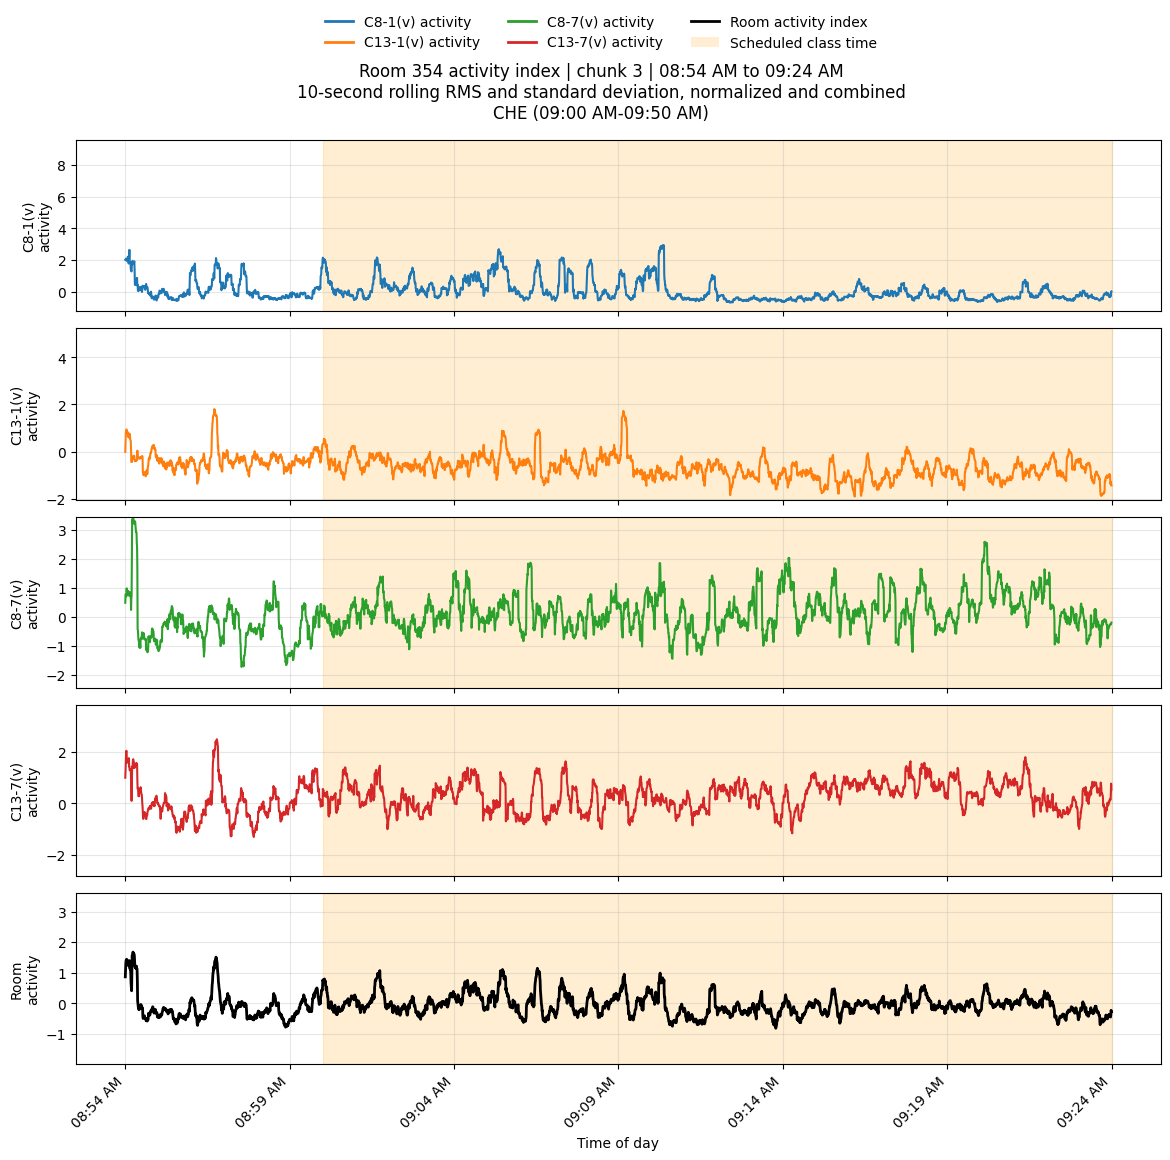

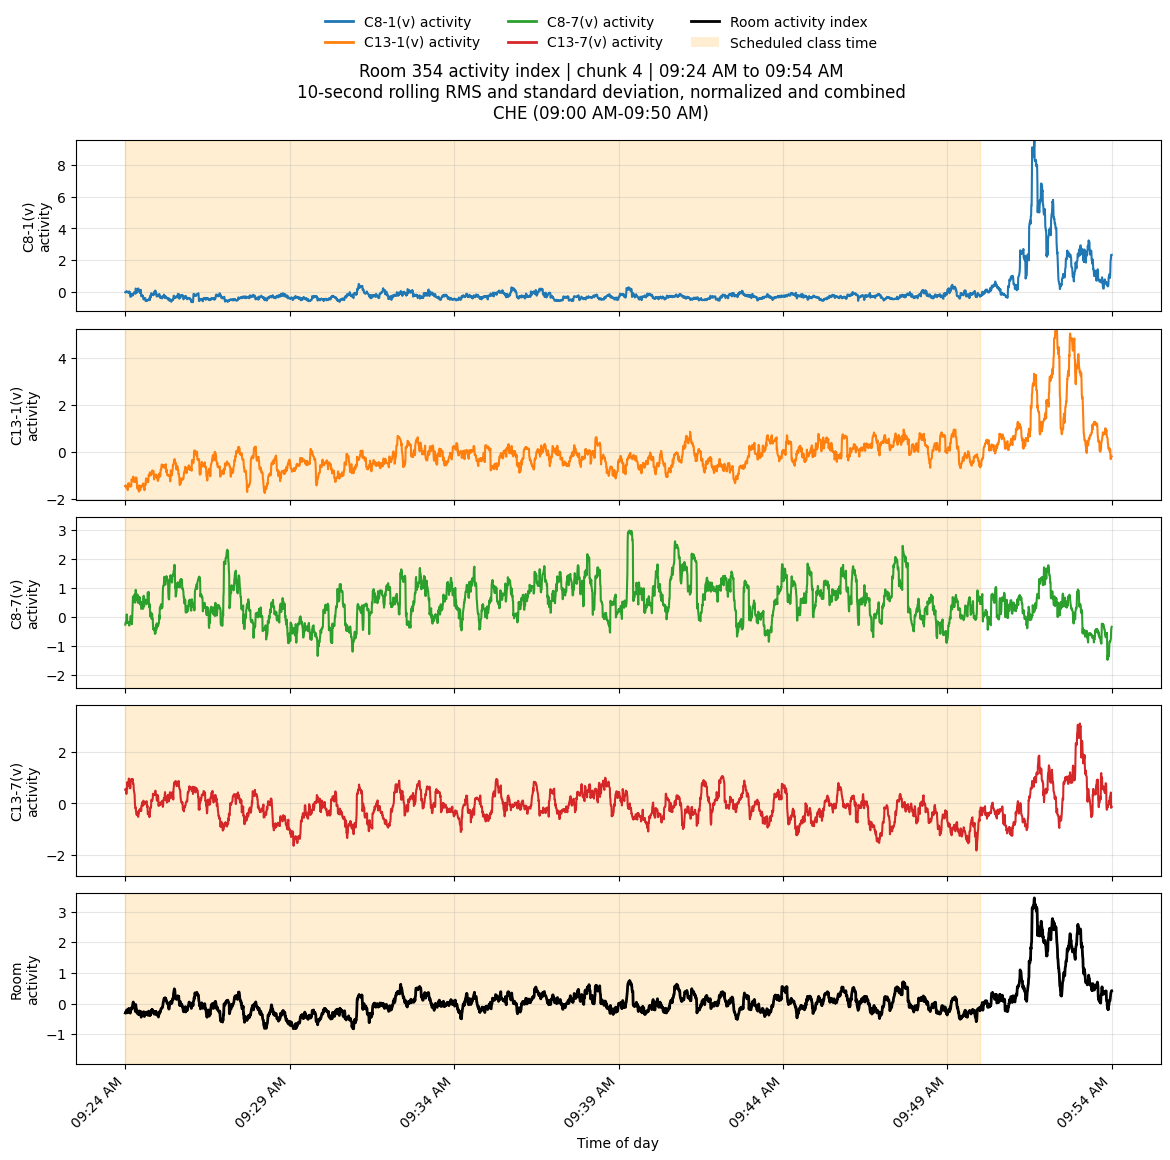

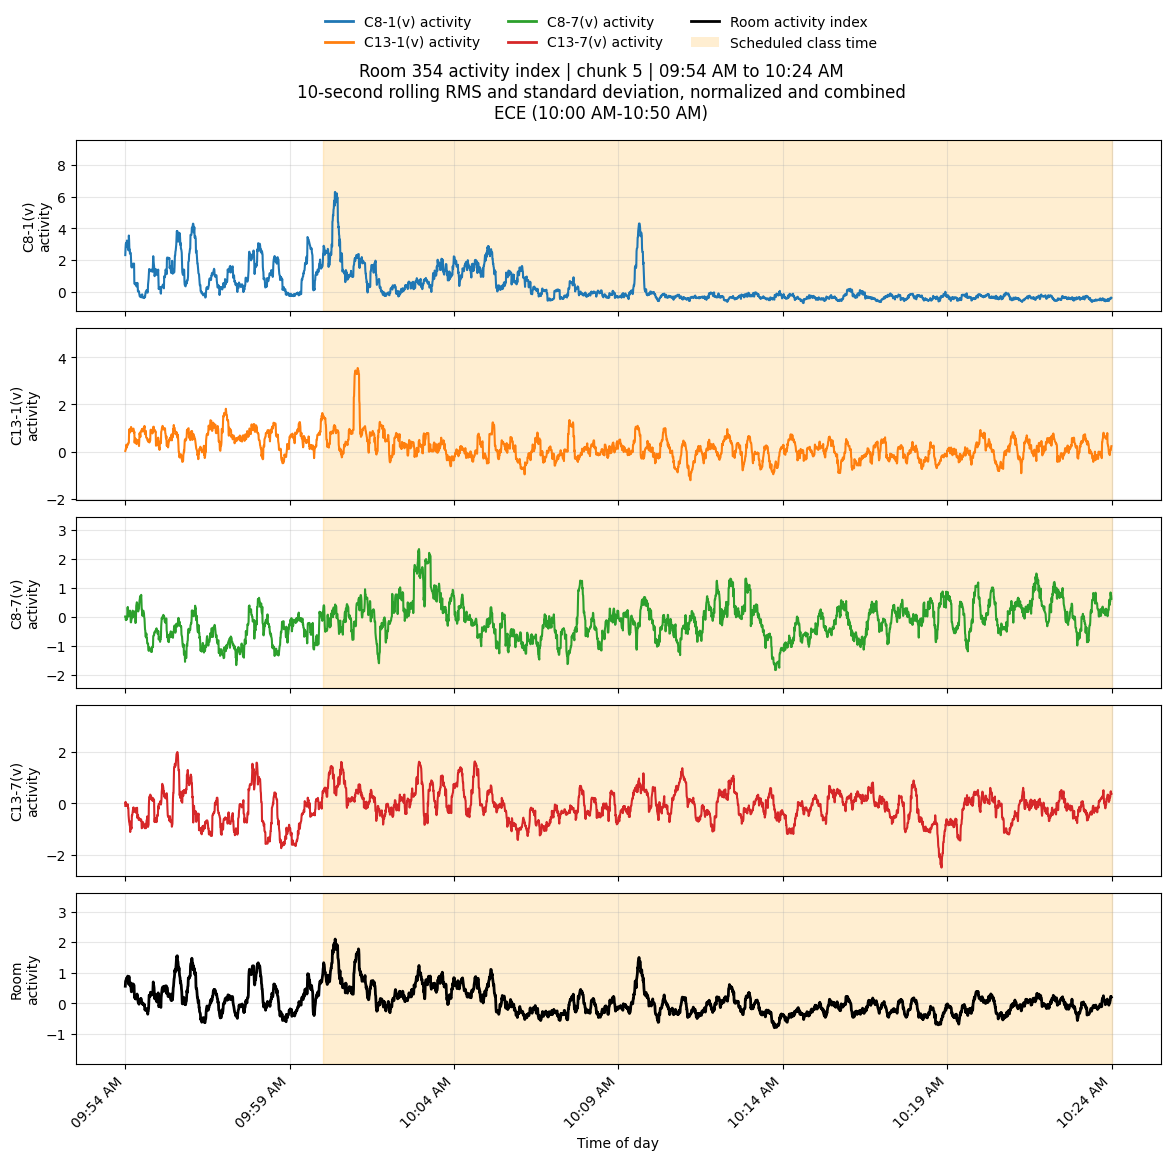

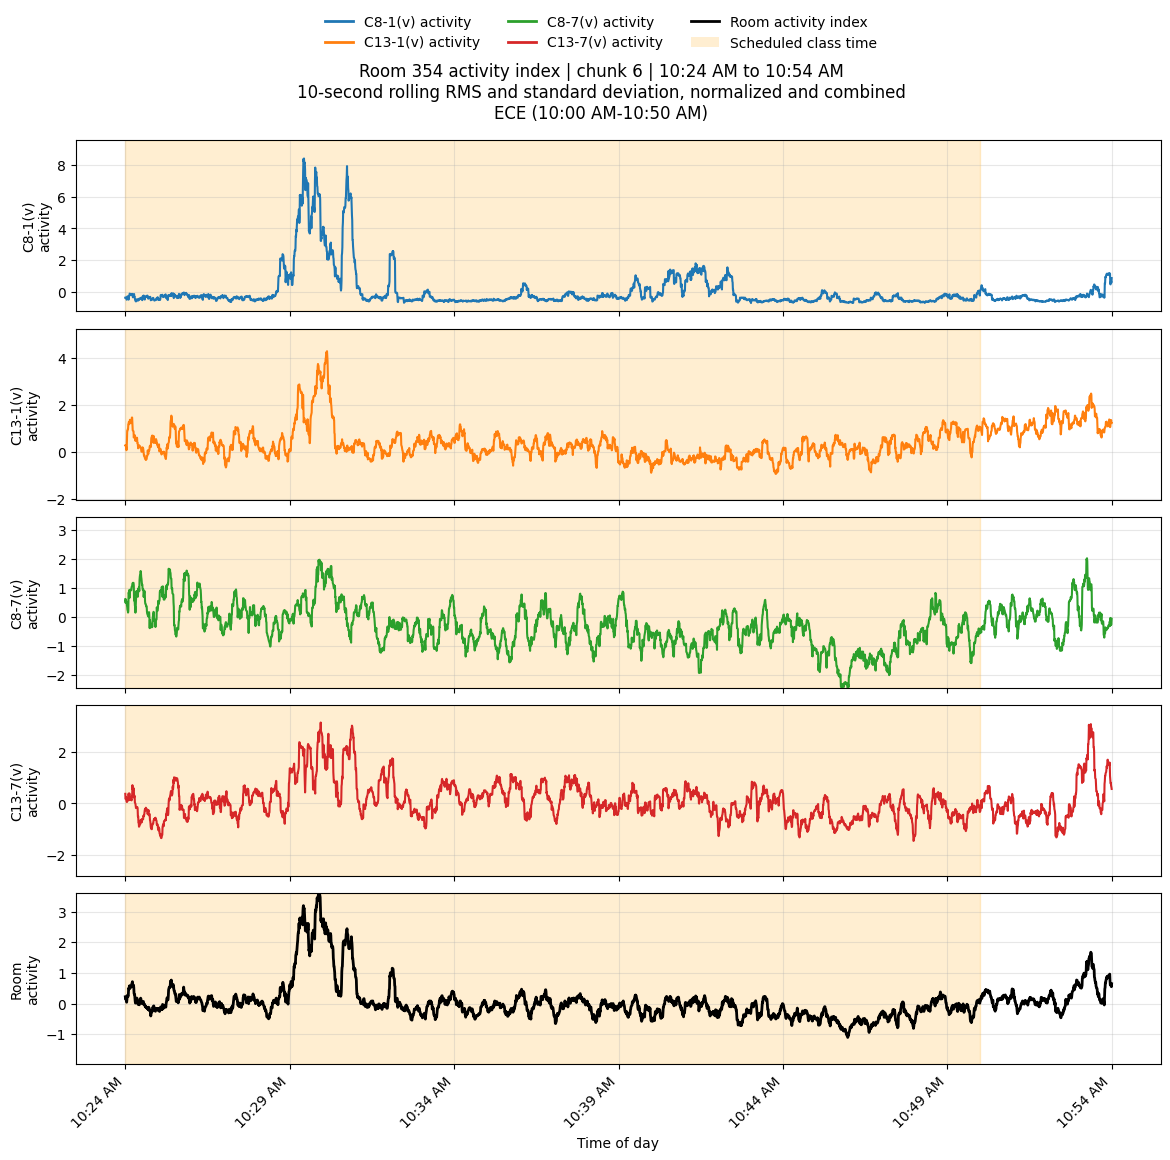

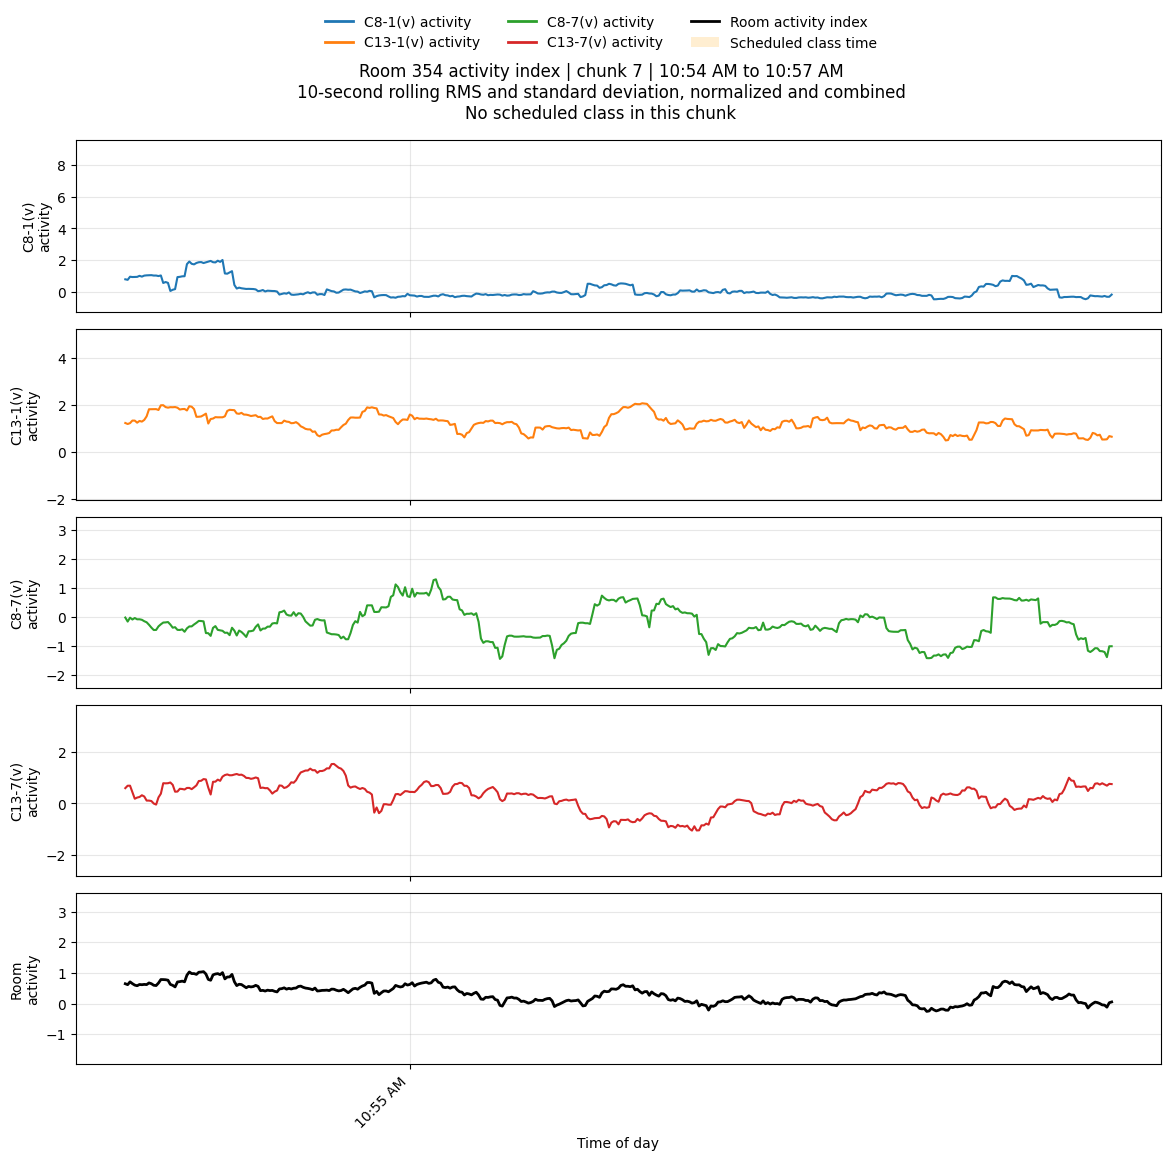

In [73]:
activity_output_dir = ROOT / 'reports' / 'figures' / 'room354_activity_chunks'
activity_output_dir.mkdir(parents=True, exist_ok=True)

activity_limits = {
    sensor: (
        activity_features[f'{sensor}_activity'].min(),
        activity_features[f'{sensor}_activity'].max(),
    )
    for sensor in sensor_columns
}
room_activity_limits = (
    activity_features['room_activity_index'].min(),
    activity_features['room_activity_index'].max(),
)

for chunk_number in range(chunk_count):
    chunk_data = activity_features.loc[activity_features['chunk'] == chunk_number]
    if chunk_data.empty:
        continue

    chunk_start = chunk_data['clock_time'].iloc[0]
    chunk_end = chunk_data['clock_time'].iloc[-1] + pd.to_timedelta(
        AVERAGE_WINDOW_SECONDS,
        unit='s',
    )
    chunk_classes = class_blocks.loc[
        (class_blocks['start'] < chunk_end) & (class_blocks['end'] > chunk_start)
    ]

    fig, axes = plt.subplots(
        len(sensor_columns) + 1,
        1,
        figsize=(14, 12),
        sharex=True,
    )

    for ax, sensor in zip(axes[:-1], sensor_columns):
        ax.plot(
            chunk_data['clock_time'],
            chunk_data[f'{sensor}_activity'],
            linewidth=1.5,
            color=sensor_colors[sensor],
        )
        for _, class_row in chunk_classes.iterrows():
            block_start = max(class_row['start'], chunk_start)
            block_end = min(class_row['end'], chunk_end)
            ax.axvspan(block_start, block_end, color='orange', alpha=0.18)
        ax.set_ylim(activity_limits[sensor])
        ax.set_ylabel(f'{sensor}\nactivity')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))

    room_ax = axes[-1]
    room_ax.plot(
        chunk_data['clock_time'],
        chunk_data['room_activity_index'],
        linewidth=2,
        color='black',
    )
    for _, class_row in chunk_classes.iterrows():
        block_start = max(class_row['start'], chunk_start)
        block_end = min(class_row['end'], chunk_end)
        room_ax.axvspan(block_start, block_end, color='orange', alpha=0.18)
    room_ax.set_ylim(room_activity_limits)
    room_ax.set_ylabel('Room\nactivity')
    room_ax.set_xlabel('Time of day')
    room_ax.grid(True, alpha=0.3)
    room_ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    room_ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))
    plt.setp(room_ax.get_xticklabels(), rotation=45, ha='right')

    sensor_handles = [
        Line2D([0], [0], color=sensor_colors[sensor], lw=2, label=f'{sensor} activity')
        for sensor in sensor_columns
    ]
    room_handle = Line2D([0], [0], color='black', lw=2, label='Room activity index')
    class_handle = Patch(facecolor='orange', alpha=0.18, label='Scheduled class time')
    fig.legend(
        handles=sensor_handles + [room_handle, class_handle],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=3,
        frameon=False,
    )

    class_text = 'No scheduled class in this chunk'
    if not chunk_classes.empty:
        class_text = '; '.join(
            f"{row.course} ({row.start:%I:%M %p}-{row.end:%I:%M %p})"
            for row in chunk_classes.itertuples()
        )

    fig.suptitle(
        f'Room 354 activity index | chunk {chunk_number + 1} | '
        f'{chunk_start:%I:%M %p} to {chunk_end:%I:%M %p}\n'
        f'{ACTIVITY_WINDOW_SECONDS}-second rolling RMS and standard deviation, normalized and combined\n'
        f'{class_text}',
        y=0.945,
    )
    fig.subplots_adjust(top=0.88, hspace=0.10)
    activity_filename = (
        f'room354_activity_chunk_{chunk_number + 1:02d}_'
        f'{chunk_start:%H%M}_to_{chunk_end:%H%M}.png'
    )
    fig.savefig(activity_output_dir / activity_filename, dpi=300, bbox_inches='tight')
    plt.show()
